# COS40007 Design Project
## Data Visualisation — Report Figures
Generates all six report figures from the cleaned combined dataset:
`combined_air_electricity_ipi_cleaned.csv`

| Figure | Description |
|--------|-------------|
| 1 | Monthly vehicle-registration line chart |
| 2 | Missing-value diagnostics — bar chart + missingness heatmap |
| 3 | Standardised monthly variables (two-panel) |
| 4 | Pearson correlation heatmap (6 key variables) |
| 5 | Histograms (6 key variables, 2 × 3 grid) |
| 6 | Boxplots (6 key variables, 2 × 3 grid) |


## 0  Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────
DATA_PATH  = "combined_air_electricity_ipi_cleaned.csv"
OUTPUT_DIR = Path(".")          # change to Path("outputs") if preferred
DPI        = 150

# ── 6 key variables used in Figures 2–6 ───────────────────────────────────
KEY_VARS = [
    "car_registration",
    "electricity_local",
    "ipi_abs_index_sa",
    "air_no2",
    "air_so2",
    "air_pm_25",
]

VAR_LABELS = {
    "car_registration":  "Car Registrations",
    "electricity_local": "Elec. Local (GWh)",
    "ipi_abs_index_sa":  "IPI – Abs. Index (SA)",
    "air_no2":           "NO₂ (µg/m³)",
    "air_so2":           "SO₂ (µg/m³)",
    "air_pm_25":         "PM₂.₅ (µg/m³)",
}
PRETTY = list(VAR_LABELS.values())

# Pre-cleaning missing counts reported in the notebook (air_pollution.csv)
PRECLEANING_MISSING = {"NO₂": 2, "SO₂": 3, "PM₂.₅": 10, "CO": 4, "O₃": 3}

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
PAL = sns.color_palette("muted")
print("Configuration ready.")


Configuration ready.


## 1  Load and Inspect the Cleaned Dataset

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Shape : {df.shape}")
print(f"Date  : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Missing values: {df.isna().sum().sum()}")
display(df.head(3))
display(df[KEY_VARS].describe().T.round(3))


Shape : (60, 20)
Date  : 2018-01-01  →  2022-12-01
Missing values: 0


,date,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa,car_registration
0,2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963,47162
1,2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625,41705
2,2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328,49810


,count,mean,std,min,25%,50%,75%,max
car_registration,60.0,50819.083,16592.008,129.000,45202.500,52460.000,62934.500,76215.000
electricity_local,60.0,12408.988,618.107,10349.142,12056.077,12485.375,12823.768,13463.730
ipi_abs_index_sa,60.0,116.331,7.924,79.766,113.035,115.158,120.355,130.293
air_no2,60.0,0.007,0.001,0.003,0.006,0.006,0.007,0.010
air_so2,60.0,0.001,0.000,0.001,0.001,0.001,0.001,0.001
air_pm_25,60.0,14.846,6.327,10.020,11.712,13.270,15.317,52.860


## 2  Helper Functions

In [4]:
def zscore(series: pd.Series) -> pd.Series:
    """Return z-score (mean = 0, SD = 1) of a series."""
    return (series - series.mean()) / series.std()

def save_fig(fig: plt.Figure, name: str) -> None:
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved → {path}")


## 3  Figure 1 — Monthly Vehicle-Registration Line Chart
Complete vehicle-registration series, January 2018 – December 2022.
The COVID-19 lockdown period (March – August 2020) is shaded in red.


Saved → figure1_car_registration.png


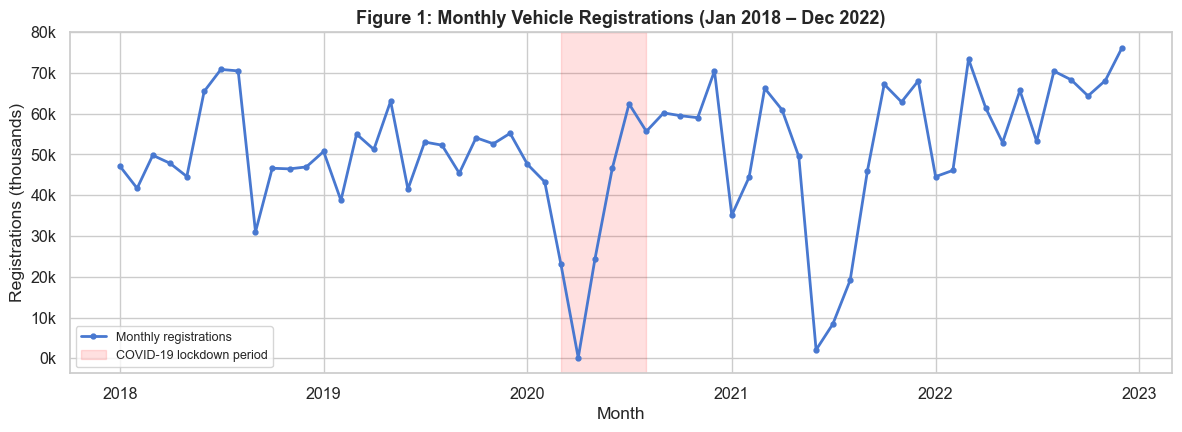

In [5]:
fig1, ax1 = plt.subplots(figsize=(12, 4.5))

ax1.plot(
    df["date"], df["car_registration"] / 1_000,
    color=PAL[0], linewidth=2, marker="o", markersize=3.5,
    label="Monthly registrations",
)
ax1.axvspan(
    pd.Timestamp("2020-03-01"), pd.Timestamp("2020-08-01"),
    alpha=0.12, color="red", label="COVID-19 lockdown period",
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax1.set_title(
    "Figure 1: Monthly Vehicle Registrations (Jan 2018 – Dec 2022)",
    fontsize=13, fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Registrations (thousands)")
ax1.legend(fontsize=9)

plt.tight_layout()
save_fig(fig1, "figure1_car_registration.png")
plt.show()


## 4  Figure 2 — Missing-Value Diagnostics
Two-part figure:
- **(a)** Bar chart of missing counts by pollutant (from the raw `air_pollution.csv` before interpolation).
- **(b)** Missingness heatmap — 6 key variables × 60 months, showing the pre-cleaning gaps.

> The cleaned CSV contains no missing values. The heatmap reconstructs
> the pre-cleaning pattern from the counts reported in the data-cleaning notebook.


In [ ]:
# Reconstruct pre-cleaning missingness for the heatmap
miss_df = df[KEY_VARS].copy()
miss_df.iloc[4:6,  KEY_VARS.index("air_no2")]   = np.nan  # NO₂:  May–Jun 2018
miss_df.iloc[7:10, KEY_VARS.index("air_so2")]   = np.nan  # SO₂:  Aug–Oct 2018
miss_df.iloc[0:10, KEY_VARS.index("air_pm_25")] = np.nan  # PM₂.₅: Jan–Oct 2018 (leading gap)

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

# ── (a) Bar chart ──────────────────────────────────────────────────────────
ax2a = axes2[0]
bars = list(PRECLEANING_MISSING.keys())
vals = list(PRECLEANING_MISSING.values())
ax2a.bar(bars, vals, color=[PAL[i] for i in range(len(bars))], edgecolor="white", width=0.6)
for i, v in enumerate(vals):
    ax2a.text(i, v + 0.1, str(v), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2a.set_title("(a) Missing Observations by Pollutant", fontweight="bold")
ax2a.set_xlabel("Pollutant")
ax2a.set_ylabel("Missing count (months)")

# ── (b) Missingness heatmap ────────────────────────────────────────────────
hm_data = miss_df.isnull().T.astype(int)
hm_data.index   = PRETTY
hm_data.columns = [d.strftime("%Y-%m") for d in df["date"]]
xtick_labels    = [d.strftime("%Y-%m") if i % 6 == 0 else "" for i, d in enumerate(df["date"])]

ax2b = axes2[1]
sns.heatmap(
    hm_data,
    cmap=["#e8f4f8", "#e74c3c"],
    cbar=False, linewidths=0.3, linecolor="#cccccc",
    ax=ax2b, xticklabels=xtick_labels,
)
ax2b.set_title(
    "(b) Missingness Heatmap — 6 Key Variables × Months\n(before preprocessing; red = missing)",
    fontweight="bold",
)
ax2b.set_xlabel("Month")
ax2b.set_yticklabels(PRETTY, rotation=0, fontsize=9)
ax2b.tick_params(axis="x", rotation=45)

legend_handles = [
    Patch(facecolor="#e74c3c", label="Missing"),
    Patch(facecolor="#e8f4f8", edgecolor="#ccc", label="Present"),
]
fig2.legend(handles=legend_handles, loc="lower center", ncol=2,
            bbox_to_anchor=(0.5, -0.05), fontsize=10)
fig2.suptitle(
    "Figure 2: Missing Observations in the Original Air-Pollution Dataset Before Preprocessing",
    fontsize=12, fontweight="bold", y=1.02,
)

plt.tight_layout()
save_fig(fig2, "figure2_missing_values.png")
plt.show()


## 5  Figure 3 — Standardised Monthly Variables (Two-Panel)
Variables are standardised to z-scores (mean = 0, SD = 1) **for visual comparison only**;
the original measurement units are not altered.

- **Panel (a):** car registrations, local electricity consumption, NO₂
- **Panel (b):** IPI – Absolute Index (seasonally adjusted), local electricity consumption, SO₂


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\1690300725.py:47: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2478006751.py:7: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(path, dpi=DPI, bbox_inches="tight")


Saved → figure3_standardised_variables.png


c:\Users\ASUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


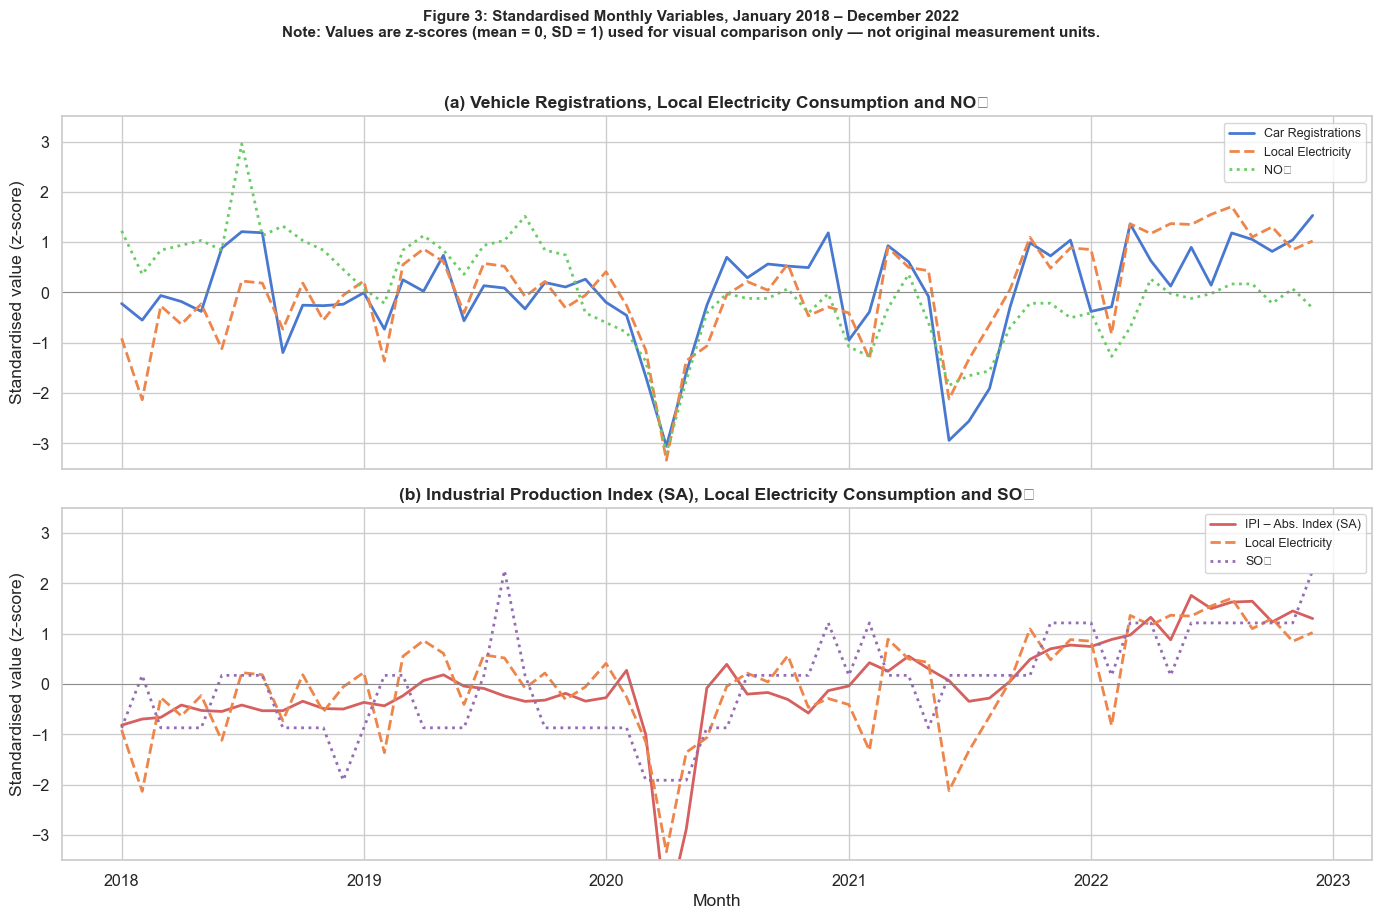

In [6]:
# Compute z-scores
for col in KEY_VARS:
    df[f"{col}_z"] = zscore(df[col])

fig3, (ax3a, ax3b) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Panel (a) ──────────────────────────────────────────────────────────────
ax3a.plot(df["date"], df["car_registration_z"],  color=PAL[0], lw=2,
          label="Car Registrations")
ax3a.plot(df["date"], df["electricity_local_z"], color=PAL[1], lw=2, ls="--",
          label="Local Electricity")
ax3a.plot(df["date"], df["air_no2_z"],           color=PAL[2], lw=2, ls=":",
          label="NO₂")
ax3a.axhline(0, color="grey", lw=0.6)
ax3a.set_title(
    "(a) Vehicle Registrations, Local Electricity Consumption and NO₂",
    fontweight="bold",
)
ax3a.set_ylabel("Standardised value (z-score)")
ax3a.legend(loc="upper right", fontsize=9)
ax3a.set_ylim(-3.5, 3.5)

# ── Panel (b) ──────────────────────────────────────────────────────────────
ax3b.plot(df["date"], df["ipi_abs_index_sa_z"], color=PAL[3], lw=2,
          label="IPI – Abs. Index (SA)")
ax3b.plot(df["date"], df["electricity_local_z"], color=PAL[1], lw=2, ls="--",
          label="Local Electricity")
ax3b.plot(df["date"], df["air_so2_z"],           color=PAL[4], lw=2, ls=":",
          label="SO₂")
ax3b.axhline(0, color="grey", lw=0.6)
ax3b.set_title(
    "(b) Industrial Production Index (SA), Local Electricity Consumption and SO₂",
    fontweight="bold",
)
ax3b.set_ylabel("Standardised value (z-score)")
ax3b.set_xlabel("Month")
ax3b.legend(loc="upper right", fontsize=9)
ax3b.set_ylim(-3.5, 3.5)

fig3.suptitle(
    "Figure 3: Standardised Monthly Variables, January 2018 – December 2022\n"
    "Note: Values are z-scores (mean = 0, SD = 1) used for visual comparison only"
    " — not original measurement units.",
    fontsize=11, fontweight="bold", y=1.02,
)

plt.tight_layout()
save_fig(fig3, "figure3_standardised_variables.png")
plt.show()


## 6  Figure 4 — Pearson Correlation Heatmap (6 Key Variables)
Limited to the six key variables to keep the heatmap readable.
All 19 numeric variables are available in `df` if needed.


c:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2599469901.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2599469901.py:23: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2478006751.py:7: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(path, dpi=DPI, bbox_inches="tight")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2478006751.py:7: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.savefig(path, dpi=DPI, bbox_inches=

Saved → figure4_correlation_heatmap.png


c:\Users\ASUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ASUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


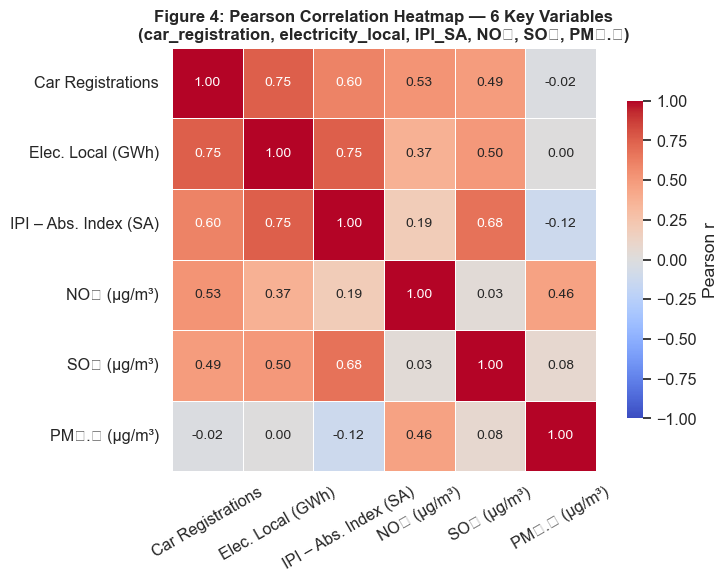

In [7]:
corr = df[KEY_VARS].corr()
corr.index   = PRETTY
corr.columns = PRETTY

fig4, ax4 = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    ax=ax4,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
)
ax4.set_title(
    "Figure 4: Pearson Correlation Heatmap — 6 Key Variables\n"
    "(car_registration, electricity_local, IPI_SA, NO₂, SO₂, PM₂.₅)",
    fontsize=12, fontweight="bold",
)
ax4.tick_params(axis="x", rotation=30)
ax4.tick_params(axis="y", rotation=0)

plt.tight_layout()
save_fig(fig4, "figure4_correlation_heatmap.png")
plt.show()


## 7  Figure 5 — Histograms (6 Key Variables, 2 × 3 Grid)
A dashed vertical line marks the mean of each variable.
Car registrations is highlighted as the primary series.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\222148602.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\222148602.py:23: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2478006751.py:7: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(path, dpi=DPI, bbox_inches="tight")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2478006751.py:7: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.savefig(path, dpi=DPI, bbox_inches="tight")


Saved → figure5_histograms.png


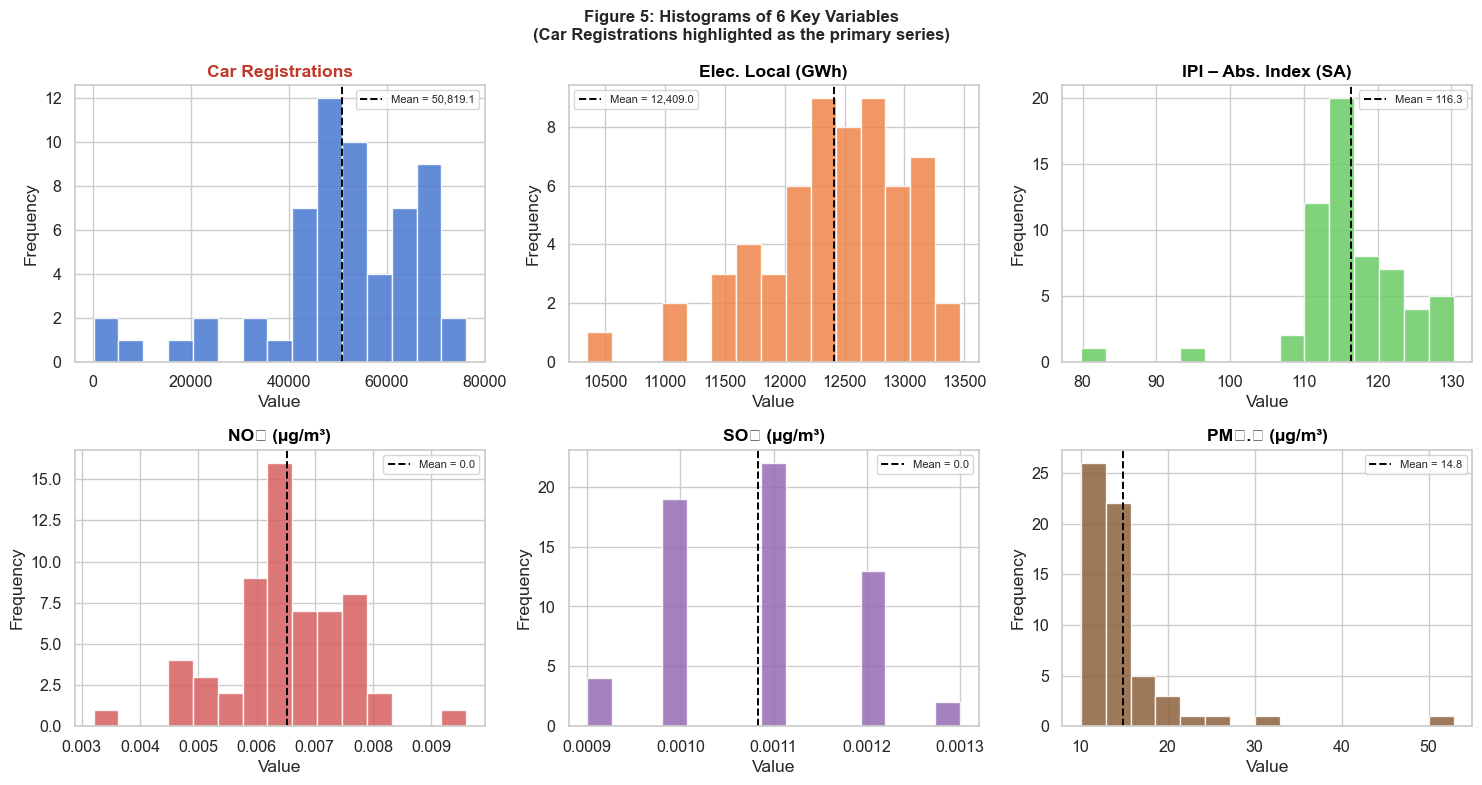

In [8]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))
axes5 = axes5.flatten()

for i, (col, label) in enumerate(VAR_LABELS.items()):
    color = PAL[0] if col == "car_registration" else PAL[i % len(PAL)]
    ax = axes5[i]
    ax.hist(df[col], bins=15, color=color, edgecolor="white", alpha=0.85)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=1.4,
               label=f"Mean = {mean_val:,.1f}")
    ax.set_title(label, fontweight="bold",
                 color="#c0392b" if col == "car_registration" else "black")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

fig5.suptitle(
    "Figure 5: Histograms of 6 Key Variables\n"
    "(Car Registrations highlighted as the primary series)",
    fontsize=12, fontweight="bold",
)

plt.tight_layout()
save_fig(fig5, "figure5_histograms.png")
plt.show()


## 8  Figure 6 — Boxplots (6 Key Variables, 2 × 3 Grid)
Box shows the IQR; whiskers extend to 1.5 × IQR; circles are outliers.
Car registrations is highlighted as the primary series.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2057782112.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2057782112.py:28: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2478006751.py:7: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(path, dpi=DPI, bbox_inches="tight")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13232\2478006751.py:7: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.savefig(path, dpi=DPI, bbox_inches="tight")


Saved → figure6_boxplots.png


c:\Users\ASUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ASUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


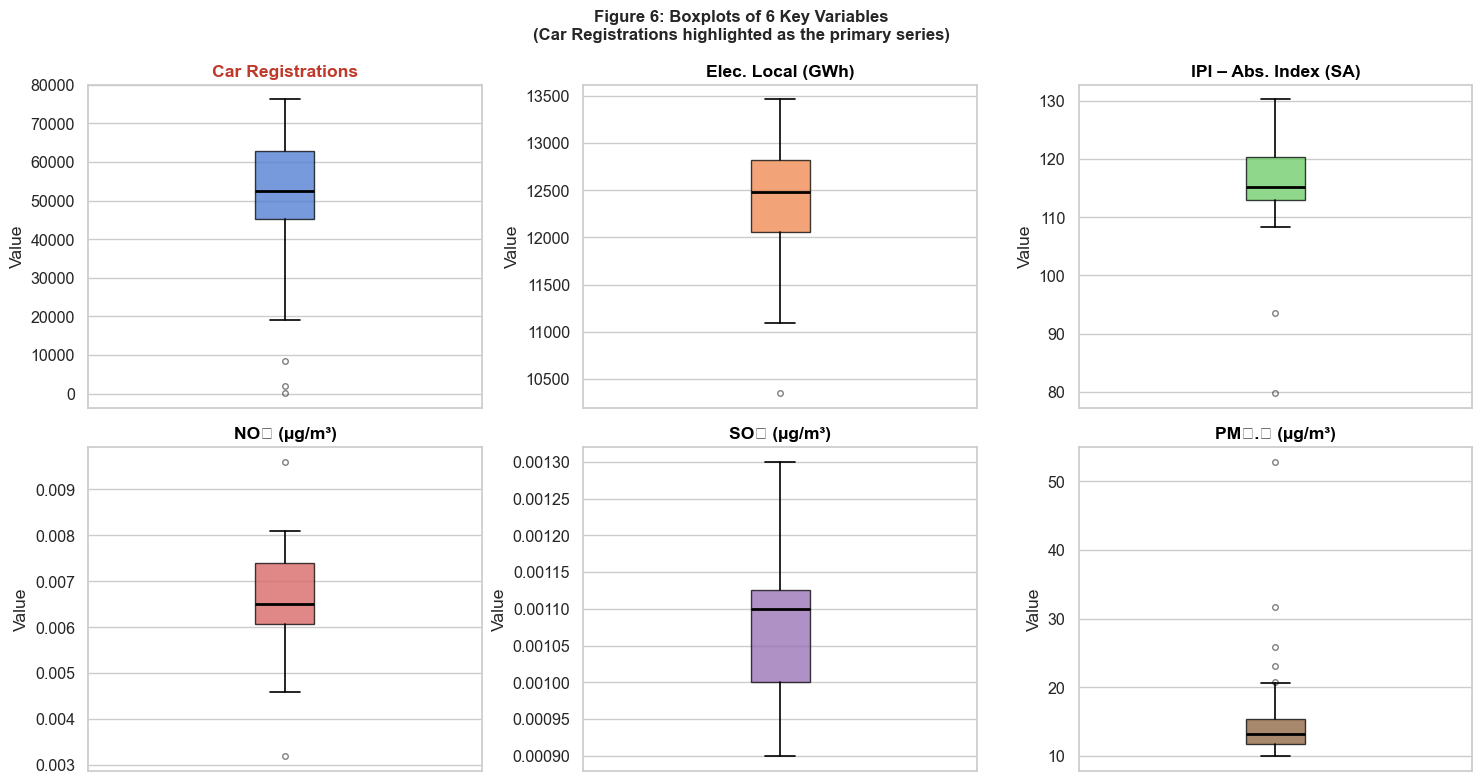

In [9]:
fig6, axes6 = plt.subplots(2, 3, figsize=(15, 8))
axes6 = axes6.flatten()

for i, (col, label) in enumerate(VAR_LABELS.items()):
    color = PAL[0] if col == "car_registration" else PAL[i % len(PAL)]
    ax = axes6[i]
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        notch=False,
        medianprops=dict(color="black", linewidth=2),
        boxprops=dict(facecolor=color, alpha=0.75),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker="o", markersize=4, alpha=0.5, color=color),
    )
    ax.set_title(label, fontweight="bold",
                 color="#c0392b" if col == "car_registration" else "black")
    ax.set_ylabel("Value")
    ax.set_xticks([])

fig6.suptitle(
    "Figure 6: Boxplots of 6 Key Variables\n"
    "(Car Registrations highlighted as the primary series)",
    fontsize=12, fontweight="bold",
)

plt.tight_layout()
save_fig(fig6, "figure6_boxplots.png")
plt.show()


In [13]:
eda = pd.read_csv("combined_air_electricity_ipi_cleaned.csv", parse_dates=["date"])
numeric_cols = eda.select_dtypes(include="number").columns.tolist()
eda.head()

,date,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa,car_registration
0,2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963,47162
1,2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625,41705
2,2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328,49810
3,2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918,47834
4,2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320,44598


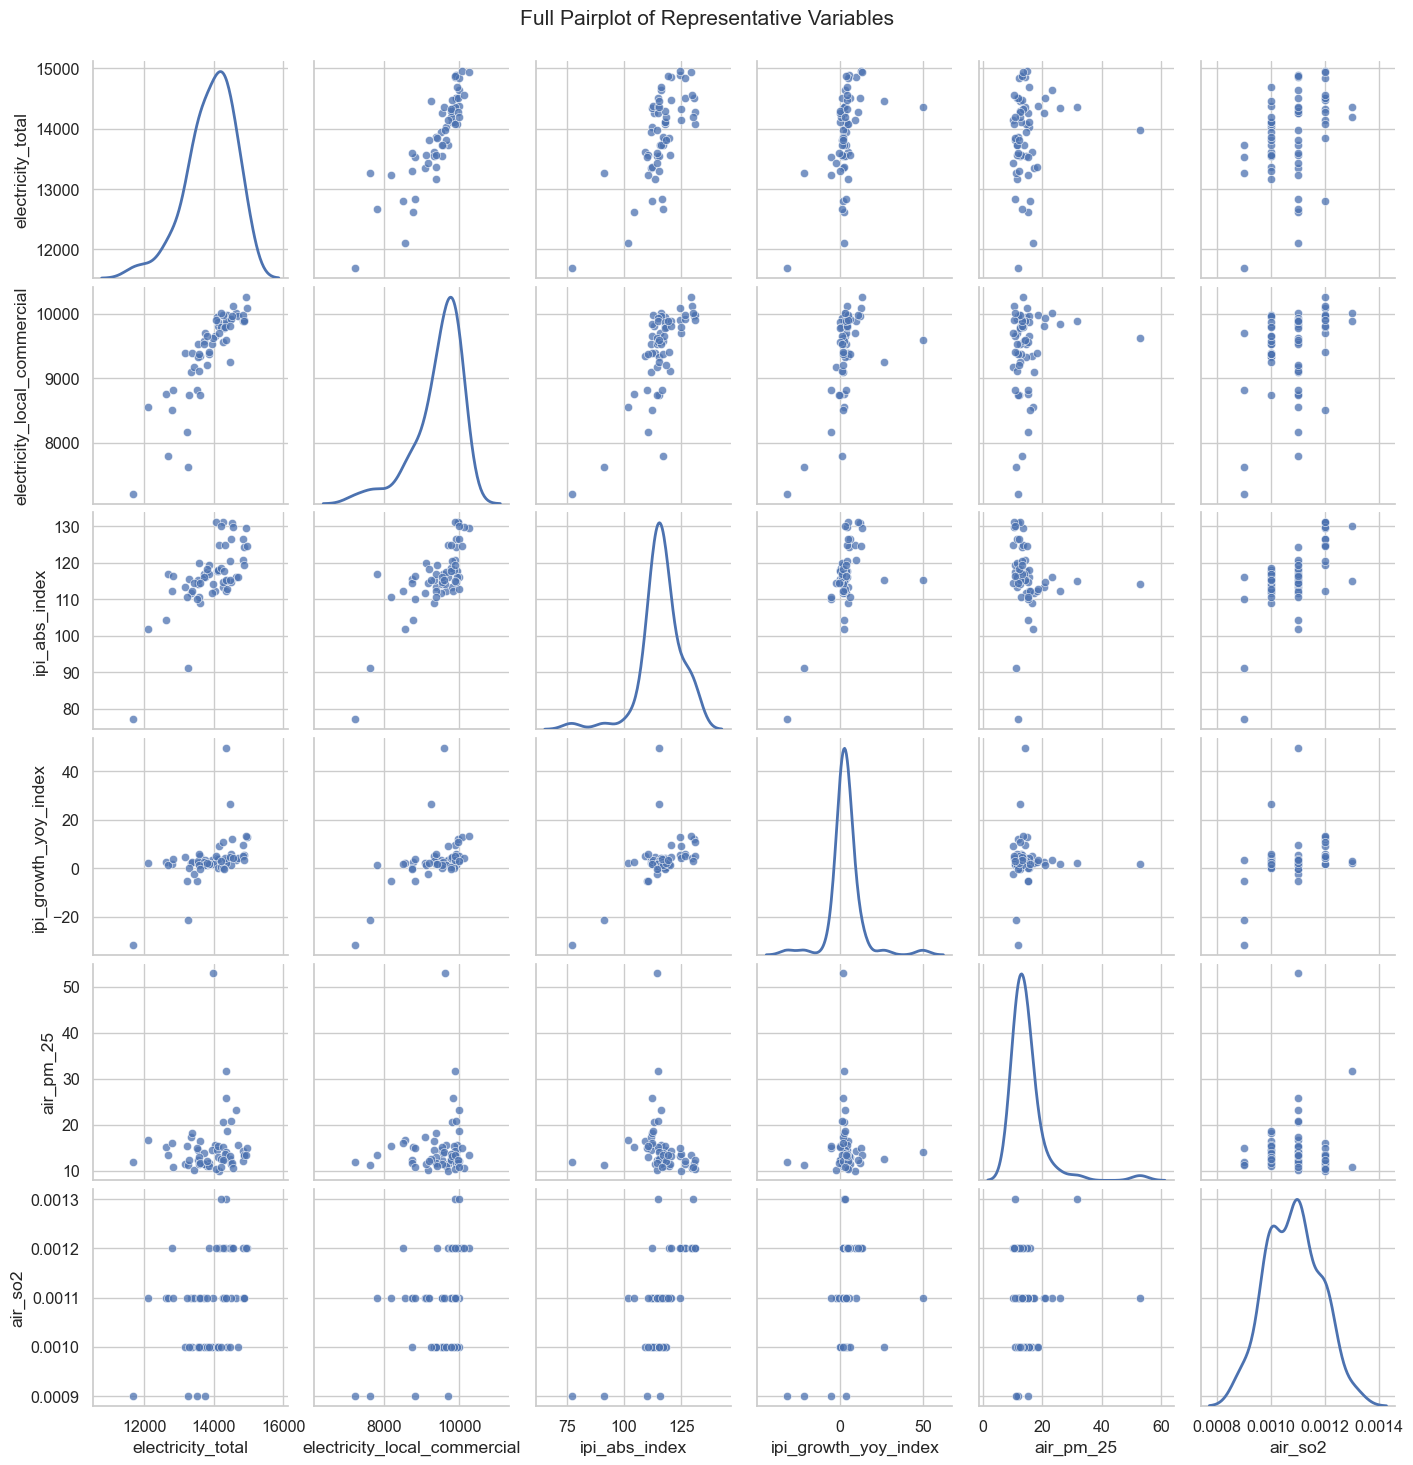

In [14]:
pairplot_cols = [
    "electricity_total",
    "electricity_local_commercial",
    "ipi_abs_index",
    "ipi_growth_yoy_index",
    "air_pm_25",
    "air_so2",
]

pair_grid = sns.pairplot(
    eda[pairplot_cols],
    diag_kind="kde",
    corner=False,
    height=2.4,
    plot_kws={"alpha": 0.75, "s": 35},
    diag_kws={"fill": False, "linewidth": 2},
)
pair_grid.fig.suptitle("Full Pairplot of Representative Variables", y=1.02)
plt.show()

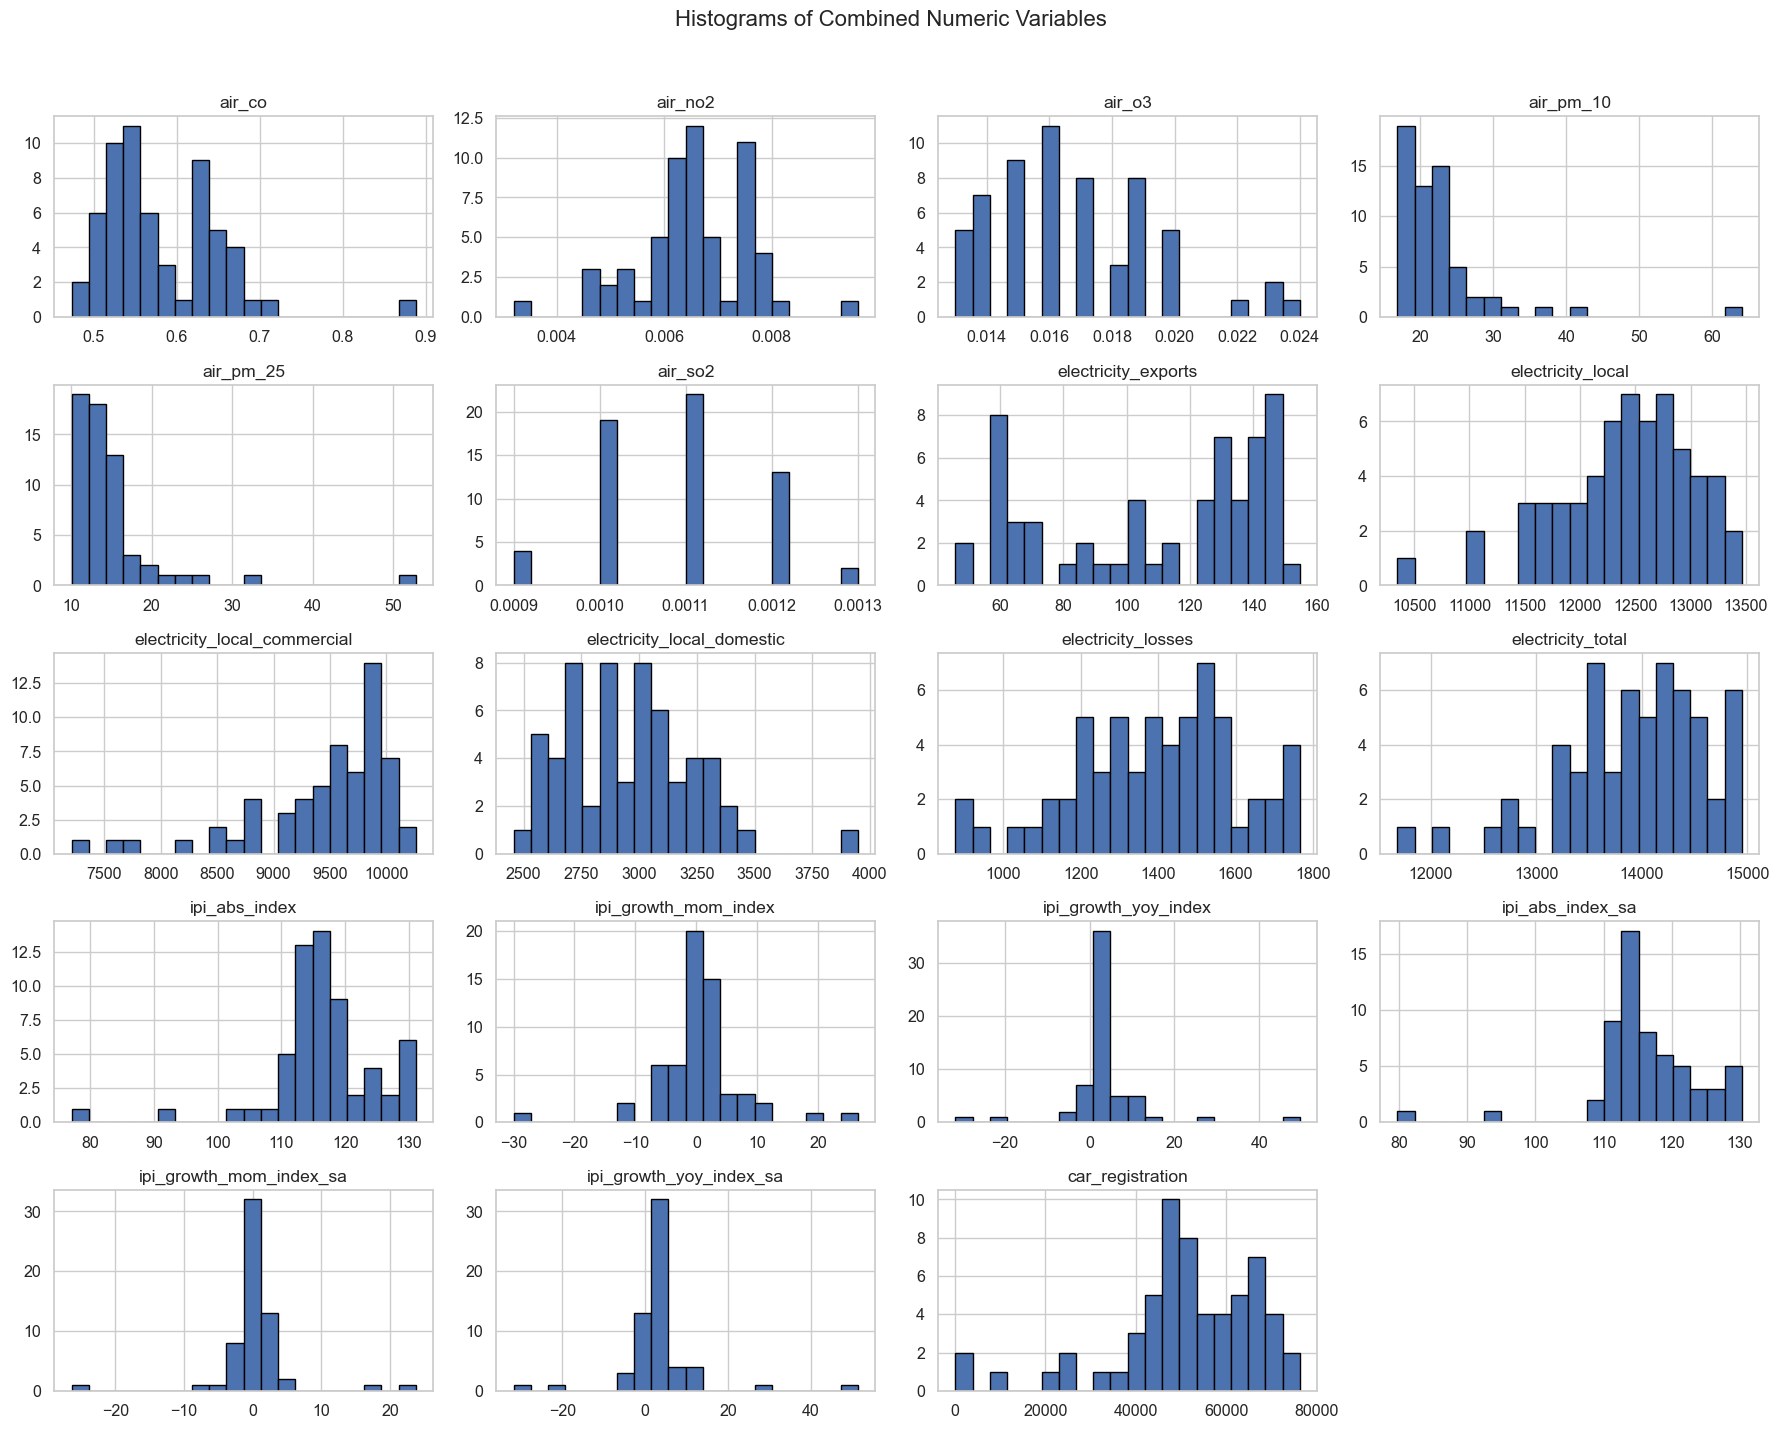

In [15]:
eda[numeric_cols].hist(bins=20, figsize=(18, 14), edgecolor="black")
plt.suptitle("Histograms of Combined Numeric Variables", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()